In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lighten_color(rgb,percentage):
    if not all(0 <= c <=1 for c in rgb): #all用来判断里面是不是都是true
        raise ValueError('RGB 的值必须在 (0,1) 范围内')
    if not (0 <= percentage <=1):
        raise ValueError('百分比必须在[0,1] 范围内')

    #讲颜色变浅,tuple表示元组
    #元组没有直接用()的推导式,需要tuple创建一个
        #直接用()表示一个生成器 这是一个迭代器
    return tuple(c + (1 - c) * percentage for c in rgb)

In [3]:
def visualize(X_square_original,
              X_grid,X_shape,title_txt):
    fig,ax = plt.subplots()

    for i in range(X_grid.shape[0]):
        plt.plot(X_grid[i,:,0],X_grid[i,:,1],'k-',linewidth = 0.5)
    for j in range(X_grid.shape[1]):
        plt.plot(X_grid[:,j,0],X_grid[:,j,1],'k-',linewidth = 0.5)

    colors = plt.cm.hsv(np.linspace(0,1,X_shape.shape[0]))
    for i in range(X_shape.shape[0]):
        plt.plot(X_shape[i,0],X_shape[i,1],'o',color = colors[i],
                 markersize = 4,zorder = 1000)
        plt.plot(X_square_original[i,0],X_square_original[i,1],'o',
                 color = lighten_color(colors[i],0.78),markersize = 4)
        plt.plot((X_shape[i,0],X_square_original[i,0]),
                 (X_shape[i,1],X_square_original[i,1]),
                  lw = 0.25,color = lighten_color(colors[i],0.78),zorder = 1)

    plt.axvline(x=0, color='k', zorder=0)  # 绘制 x 轴
    plt.axhline(y=0, color='k', zorder=0)  # 绘制 y 轴

    #控制xy轴,控制主副刻度,length同时控制两个刻度隐藏,xy的label都关了
    ax.tick_params(axis = 'both',which = 'both',length = 0,
                   labelbottom = False,labelleft = False) 
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect(1) #和'equal'等价
    ax.set_xlim([-3, 3])  # x轴范围
    ax.set_ylim([-3, 3])  # y轴范围
    ax.grid(linestyle='--', linewidth=0.15, color=[0.8, 0.8, 0.8])  # 添加网格
    plt.title(title_txt)  # 设置图标题

In [5]:
def generate_square_border_scatter(n):
    x = np.linspace(-1,1,n)
    #full_like这里和ones_like很像 但是这里可以指定生成的数值
    top = np.column_stack((x,np.full_like(x,1)))
    #flip是快速反转,因为是依次连接,翻转两次
    bottom = np.column_stack((np.flip(x),np.full_like(x,-1)))
    right = np.column_stack((np.full_like(x,1),np.flip(x)))
    left = np.column_stack((np.full_like(x,-1),x))

    points = np.vstack((top,right,bottom,left)) #和row_stack等价

    return points

In [6]:
x_vals = np.arange(-10,10+1)
y_vals = np.arange(-10,10+1)
X1,X2 = np.meshgrid(x_vals,y_vals)
#创建一个维度,3维度堆叠
X_grid = np.stack([X1,X2],axis = 2)

In [7]:
X_vec = np.array([[1,0],
                  [0,1]]) #初始坐标轴向量

In [8]:
X_square = generate_square_border_scatter(20)

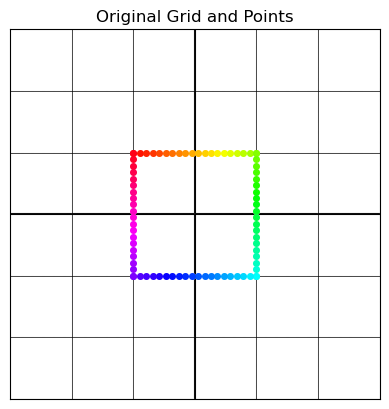

In [11]:
visualize(X_square,
          X_grid,
          X_square,
          'Original Grid and Points')

In [17]:
t1 = np.array([[-1.5],
               [1]])

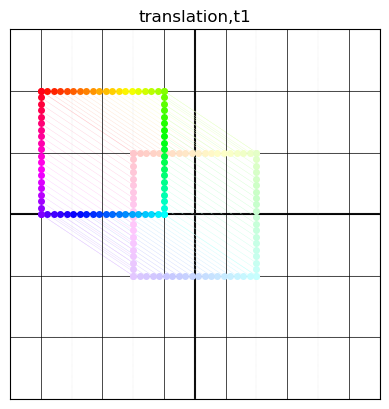

In [18]:
visualize(X_square,
          X_grid + t1.T,
          X_square + t1.T,
          'translation,t1')

In [19]:
t2 = -t1

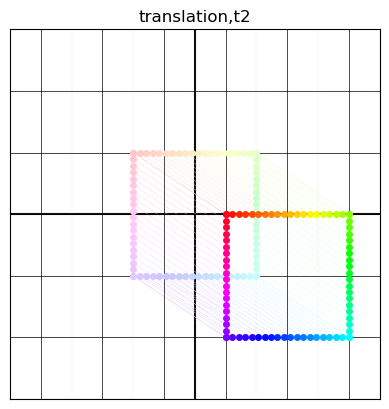

In [20]:
visualize(X_square,
          X_grid + t2.T,
          X_square + t2.T,
          'translation,t2')

In [22]:
S_up = np.array([[2,0],
                 [0,2]])

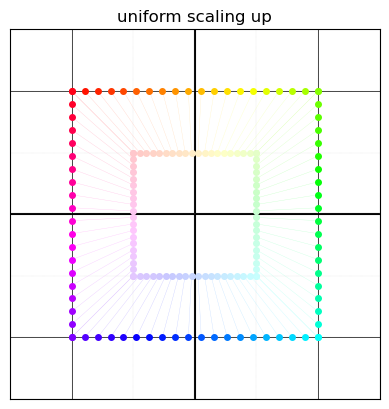

In [23]:
visualize(X_square,
          X_grid @ S_up.T,
          X_square @ S_up.T,
          'uniform scaling up')

In [24]:
S_down = np.linalg.inv(S_up)
S_down

array([[0.5, 0. ],
       [0. , 0.5]])

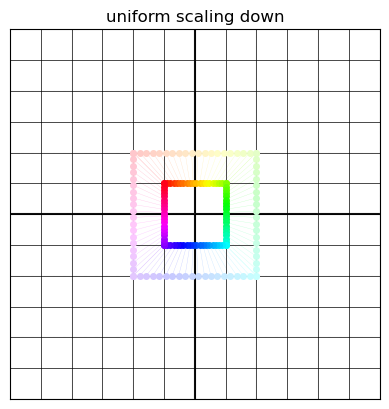

In [25]:
visualize(X_square,
          X_grid @ S_down.T,
          X_square @ S_down.T,
          'uniform scaling down')

In [27]:
def rotation_matrix(theta):
    return np.array([[np.cos(theta), - np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])

In [28]:
angle = 2*np.pi / 3
R = rotation_matrix(angle)

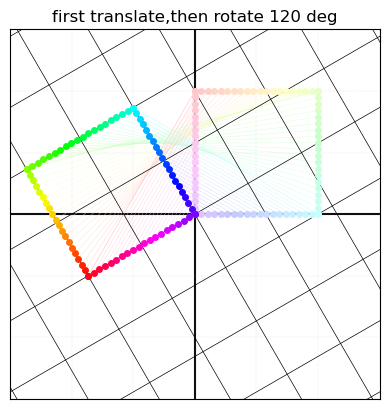

In [29]:
t_1 = np.array([[1],
                [1]])

visualize(X_square + t_1.T,
          (X_grid + t_1.T) @ R.T,
          (X_square + t_1.T) @ R.T,
          'first translate,then rotate 120 deg')